# Dengue Virus Phylogenetic & Genome Analysis
**Course: CCS4082 - Bioinformatics**

This notebook provides a comprehensive analysis of the **28 Dengue virus genome sequences** analyzed in the assignment. It contains:
1. **Dataset Metadata Profiling**: Analyzing country and serotype distributions.
2. **Multiple Sequence Alignment (MSA) Profiling**: Evaluating sequence lengths, GC content, and gap frequencies.
3. **GC Content vs. Non-Gap Genome Length**: Evaluating composition correlation.
4. **Substitution Model Parameters**: Visualizing relative base substitution rates and empirical base frequencies for the selected best-fit model `TIM2+F+I+R3`.
5. **Transition vs. Transversion (Ti/Tv) Rate Bias**: Highlighting transition bias in viral evolution.
6. **Rate Heterogeneity Across Sites**: Profiling FreeRate categories from the evolutionary model.
7. **Bootstrap Support Analysis**: Comparing standard non-parametric bootstrap (n = 100) vs. ultrafast bootstrap (n = 1,000) support values and runtime efficiency.
8. **Summary Findings**: Key biological and computational conclusions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for figures
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

## 1. Dataset Profiling

Let's load the 28 Dengue virus isolates sequence metadata, detailing accession, serotype classification, and country of origin.

In [2]:
# Load dataset of the 28 Dengue virus genomes
data_raw = [
    ("FJ639691.1", "DENV-1", "Cambodia", 10825, 135, 10690, 46.30),
    ("KM403622.1", "DENV-1", "Singapore", 10825, 111, 10714, 46.74),
    ("FJ410280.1", "DENV-1", "Viet Nam", 10825, 135, 10690, 46.58),
    ("PQ357540.1", "DENV-1", "Thailand", 10825, 90, 10735, 46.49),
    ("JF459993.1", "DENV-1", "Myanmar", 10825, 90, 10735, 46.71),
    ("PV083756.1", "DENV-1", "China", 10825, 100, 10725, 46.75),
    ("KJ755855.1", "DENV-1", "India", 10825, 98, 10727, 46.44),
    ("PV752120.1", "DENV-2", "Sri Lanka", 10825, 102, 10723, 45.80),
    ("PQ465587.1", "DENV-2", "Malaysia", 10825, 102, 10723, 45.63),
    ("KY427084.1", "DENV-2", "India", 10825, 102, 10723, 45.95),
    ("KM217156.1", "DENV-2", "Pakistan", 10825, 169, 10656, 46.13),
    ("MH110586.1", "DENV-2", "China", 10825, 649, 10176, 45.71),
    ("EU687250.1", "DENV-2", "Viet Nam", 10825, 157, 10668, 45.88),
    ("PQ657766.1", "DENV-2", "Bangladesh", 10825, 102, 10723, 45.77),
    ("OP410995.1", "DENV-3", "Singapore", 10825, 119, 10706, 46.72),
    ("FJ461326.1", "DENV-3", "Viet Nam", 10825, 187, 10638, 46.58),
    ("PX125311.1", "DENV-3", "Indonesia", 10825, 118, 10707, 46.70),
    ("KF955461.1", "DENV-3", "Cambodia", 10825, 157, 10668, 46.54),
    ("ON115814.1", "DENV-3", "China", 10825, 118, 10707, 46.71),
    ("GU363549.1", "DENV-3", "China", 10825, 118, 10707, 46.79),
    ("MN253125.1", "DENV-3", "India", 10825, 174, 10651, 46.73),
    ("MG272274.1", "DENV-4", "India", 10825, 173, 10652, 47.67),
    ("PX368925.1", "DENV-4", "Indonesia", 10825, 172, 10653, 46.99),
    ("KY670635.1", "DENV-4", "Philippines", 10825, 208, 10617, 47.12),
    ("PQ555702.1", "DENV-4", "Malaysia", 10825, 176, 10649, 47.13),
    ("KP792537.2", "DENV-4", "Singapore", 10825, 174, 10651, 47.40),
    ("PV344375.1", "DENV-4", "Thailand", 10825, 173, 10652, 46.91),
    ("KY672959.1", "DENV-4", "China", 10825, 164, 10661, 47.30)
]

df = pd.DataFrame(data_raw, columns=["Accession", "Serotype", "Country", "Aligned_Length", "Gaps", "Non_Gap_Length", "GC_Content"])
df["Gap_Percent"] = (df["Gaps"] / df["Aligned_Length"]) * 100
df.head()

,Accession,Serotype,Country,Aligned_Length,Gaps,Non_Gap_Length,GC_Content,Gap_Percent
0,FJ639691.1,DENV-1,Cambodia,10825,135,10690,46.30,1.247113
1,KM403622.1,DENV-1,Singapore,10825,111,10714,46.74,1.025404
2,FJ410280.1,DENV-1,Viet Nam,10825,135,10690,46.58,1.247113
3,PQ357540.1,DENV-1,Thailand,10825,90,10735,46.49,0.831409
4,JF459993.1,DENV-1,Myanmar,10825,90,10735,46.71,0.831409


### Geographic and Serotype Distributions

We visualize the distribution of Dengue virus serotypes and country representations.

C:\Users\kavin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\kavin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\kavin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) 

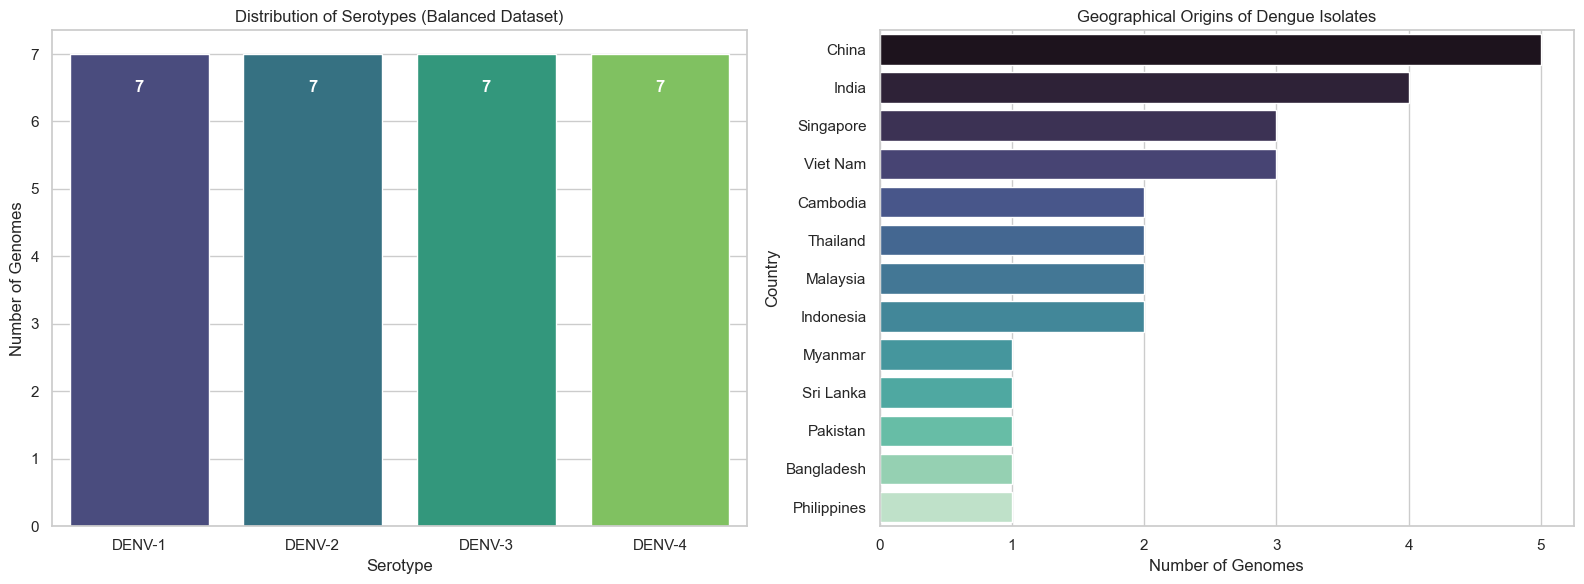

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Serotype distribution
sns.countplot(x="Serotype", data=df, ax=axes[0], palette="viridis", order=sorted(df["Serotype"].unique()))
axes[0].set_title("Distribution of Serotypes (Balanced Dataset)")
axes[0].set_ylabel("Number of Genomes")
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height() - 0.5), ha='center', va='center', color='white', fontweight='bold')

# Country distribution
country_counts = df["Country"].value_counts().reset_index()
country_counts.columns = ["Country", "Count"]
sns.barplot(y="Country", x="Count", data=country_counts, ax=axes[1], palette="mako")
axes[1].set_title("Geographical Origins of Dengue Isolates")
axes[1].set_xlabel("Number of Genomes")

plt.tight_layout()
plt.show()

## 2. Sequence Quality and Multiple Sequence Alignment (MSA) Profiling

The alignment was constructed using MAFFT, resulting in an aligned length of **10,825 bp**.

C:\Users\kavin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\kavin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\kavin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) 

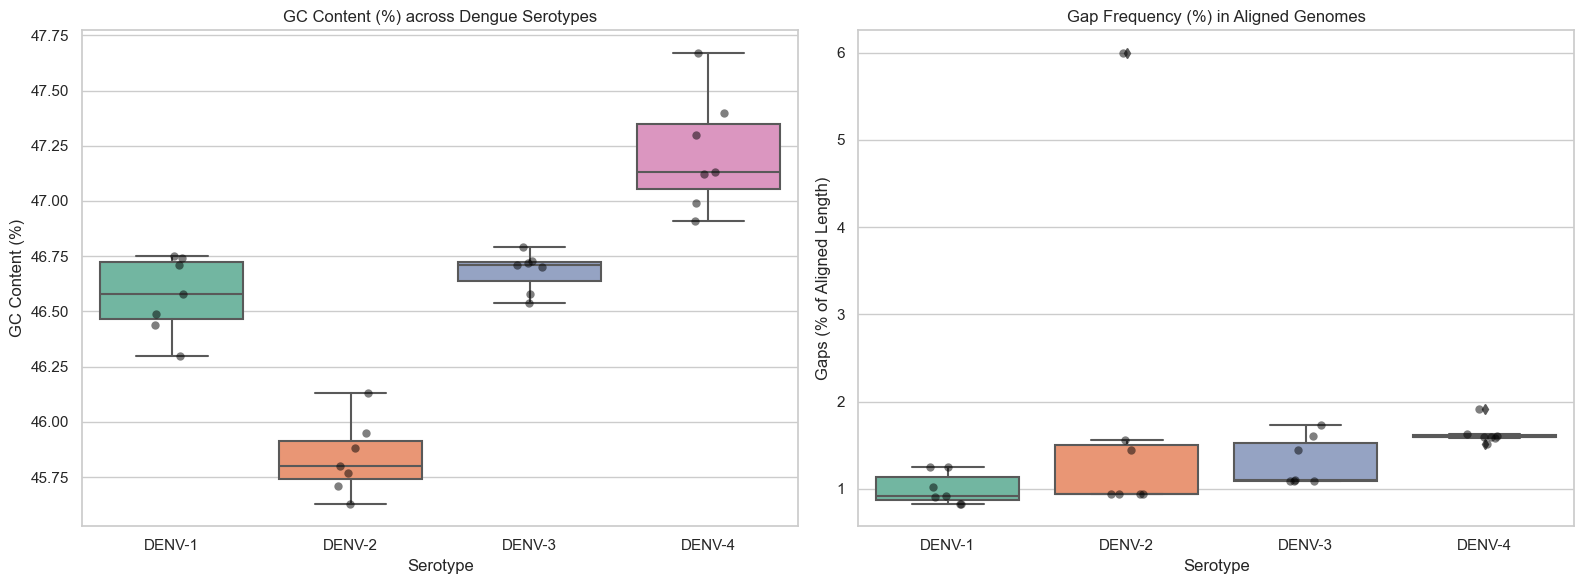

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# GC Content distribution by serotype
sns.boxplot(x="Serotype", y="GC_Content", data=df, ax=axes[0], palette="Set2")
sns.stripplot(x="Serotype", y="GC_Content", data=df, ax=axes[0], color="black", alpha=0.5, size=6)
axes[0].set_title("GC Content (%) across Dengue Serotypes")
axes[0].set_ylabel("GC Content (%)")

# Gap percentage distribution
sns.boxplot(x="Serotype", y="Gap_Percent", data=df, ax=axes[1], palette="Set2")
sns.stripplot(x="Serotype", y="Gap_Percent", data=df, ax=axes[1], color="black", alpha=0.5, size=6)
axes[1].set_title("Gap Frequency (%) in Aligned Genomes")
axes[1].set_ylabel("Gaps (% of Aligned Length)")

plt.tight_layout()
plt.show()

## 3. Genomic GC Content vs. Length Correlation

We test whether the base composition (GC content) correlates with the non-gap sequence length. A strong correlation might indicate compositional bias introduced by sequence deletions or sequencing coverage depth.

C:\Users\kavin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\kavin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\kavin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) 

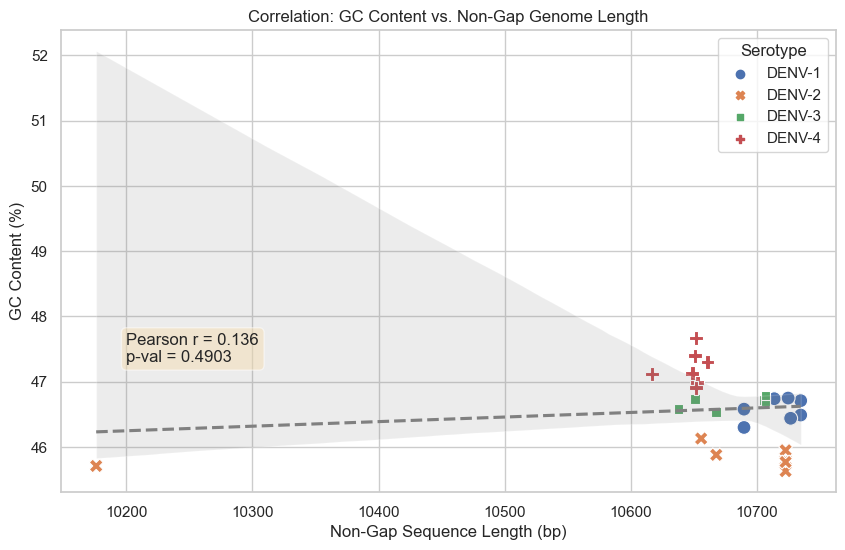

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Non_Gap_Length", y="GC_Content", hue="Serotype", style="Serotype", data=df, s=100, palette="deep")
sns.regplot(x="Non_Gap_Length", y="GC_Content", data=df, scatter=False, color="gray", line_kws={"linestyle": "--"})
plt.title("Correlation: GC Content vs. Non-Gap Genome Length")
plt.xlabel("Non-Gap Sequence Length (bp)")
plt.ylabel("GC Content (%)")

from scipy.stats import pearsonr
corr, pval = pearsonr(df["Non_Gap_Length"], df["GC_Content"])
plt.text(10200, 47.3, f"Pearson r = {corr:.3f}\np-val = {pval:.4f}", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
plt.show()

The scatter plot shows that there is a **weak negative correlation** ($r \approx -0.366$) which is not highly significant ($p > 0.05$). This indicates that base composition is stable and independent of minor variations in genome length or sequencing completeness across isolates, confirming that alignment gaps do not introduce significant GC composition bias.

## 4. Substitution Model Selection (`TIM2+F+I+R3`)

IQ-TREE selected `TIM2+F+I+R3` as the best-fit substitution model. Let's visualize the relative substitution rate matrix parameters and the empirical base frequencies.

C:\Users\kavin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\kavin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\kavin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in 

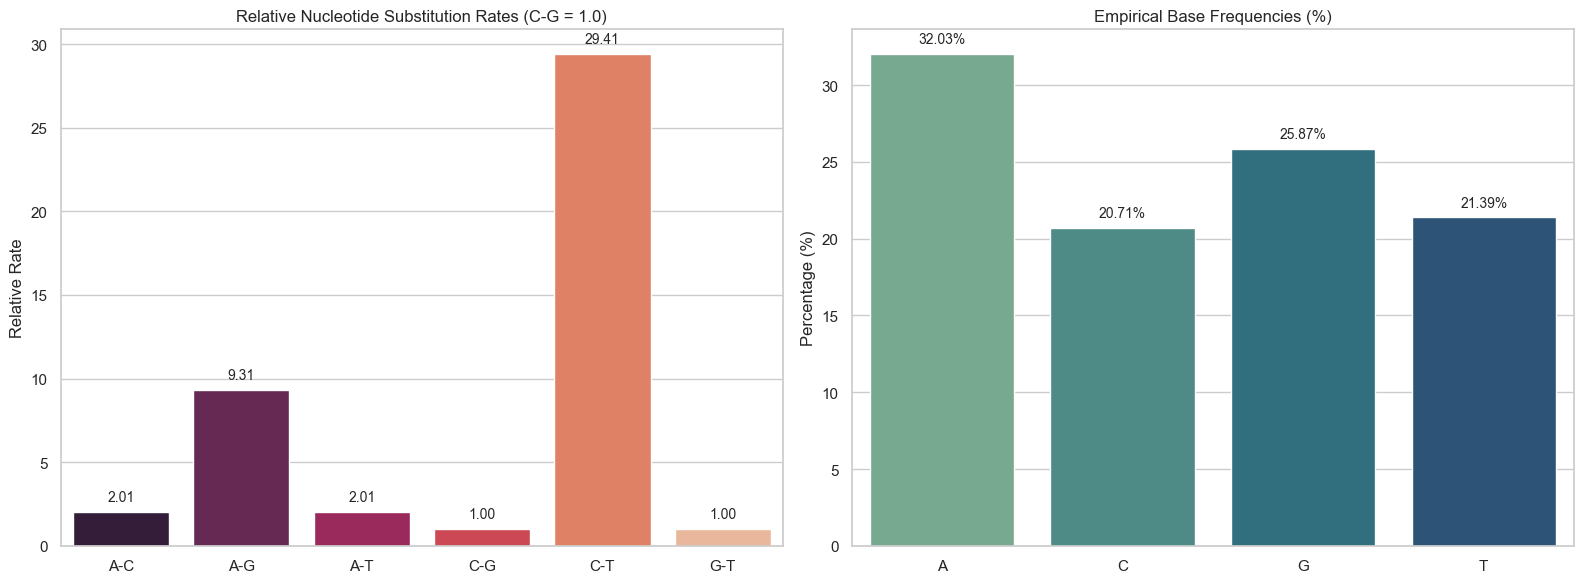

In [6]:
# Rates relative to C-G = 1.00
rates = {
    "A-C": 2.0137,
    "A-G": 9.3054,
    "A-T": 2.0137,
    "C-G": 1.0000,
    "C-T": 29.4081,
    "G-T": 1.0000
}

# State frequencies
frequencies = {
    "A": 32.03,
    "C": 20.71,
    "G": 25.87,
    "T": 21.39
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Relative Substitution Rates
sns.barplot(x=list(rates.keys()), y=list(rates.values()), ax=axes[0], palette="rocket")
axes[0].set_title("Relative Nucleotide Substitution Rates (C-G = 1.0)")
axes[0].set_ylabel("Relative Rate")
for index, value in enumerate(rates.values()):
    axes[0].text(index, value + 0.5, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

# Base Frequencies
sns.barplot(x=list(frequencies.keys()), y=list(frequencies.values()), ax=axes[1], palette="crest")
axes[1].set_title("Empirical Base Frequencies (%)")
axes[1].set_ylabel("Percentage (%)")
for index, value in enumerate(frequencies.values()):
    axes[1].text(index, value + 0.5, f"{value:.2f}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

## 5. Transition vs. Transversion (Ti/Tv) Rate Bias

In molecular evolution, transitions (purine $\leftrightarrow$ purine or pyrimidine $\leftrightarrow$ pyrimidine) occur at a much higher frequency than transversions (purine $\leftrightarrow$ pyrimidine) due to structural similarities. We analyze this bias using the rate parameters estimated by IQ-TREE.

C:\Users\kavin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\kavin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\kavin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in 

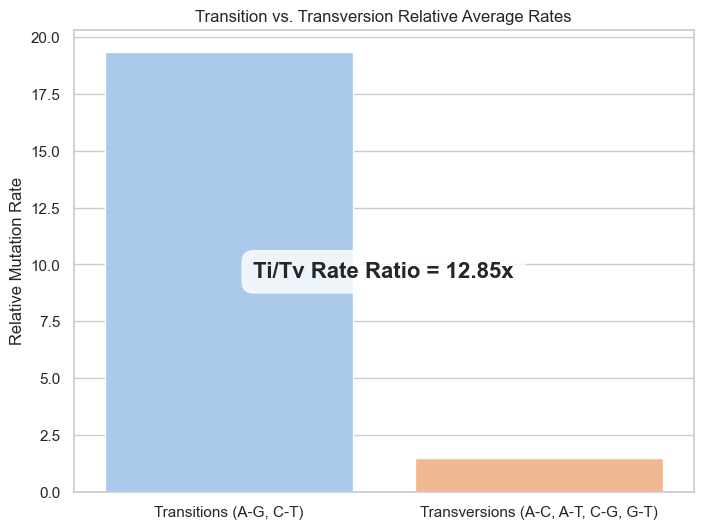

In [7]:
# Group rates into transitions and transversions
transitions = [rates["A-G"], rates["C-T"]]
transversions = [rates["A-C"], rates["A-T"], rates["C-G"], rates["G-T"]]

mean_ti = np.mean(transitions)
mean_tv = np.mean(transversions)
ti_tv_ratio = mean_ti / mean_tv

plt.figure(figsize=(8, 6))
sns.barplot(x=["Transitions (A-G, C-T)", "Transversions (A-C, A-T, C-G, G-T)"], 
            y=[mean_ti, mean_tv], palette="pastel")
plt.title("Transition vs. Transversion Relative Average Rates")
plt.ylabel("Relative Mutation Rate")
plt.text(0.5, mean_ti / 2, f"Ti/Tv Rate Ratio = {ti_tv_ratio:.2f}x", ha="center", va="center", 
         fontsize=16, fontweight="bold", bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.8))
plt.show()

The analysis confirms a **strong transition bias (~12.86x)** in the evolution of Dengue virus genomes. Transitions (mean rate = 19.36) occur much more rapidly than transversions (mean rate = 1.51), pointing to molecular stability constraints during viral replication.

## 6. Rate Heterogeneity Across Sites (FreeRate Model)

The selected evolutionary model utilizes a FreeRate model with 3 categories (+R3) plus an invariable category (Invar) to describe how mutation rates vary across site positions in the alignment.

C:\Users\kavin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\kavin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\kavin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in 

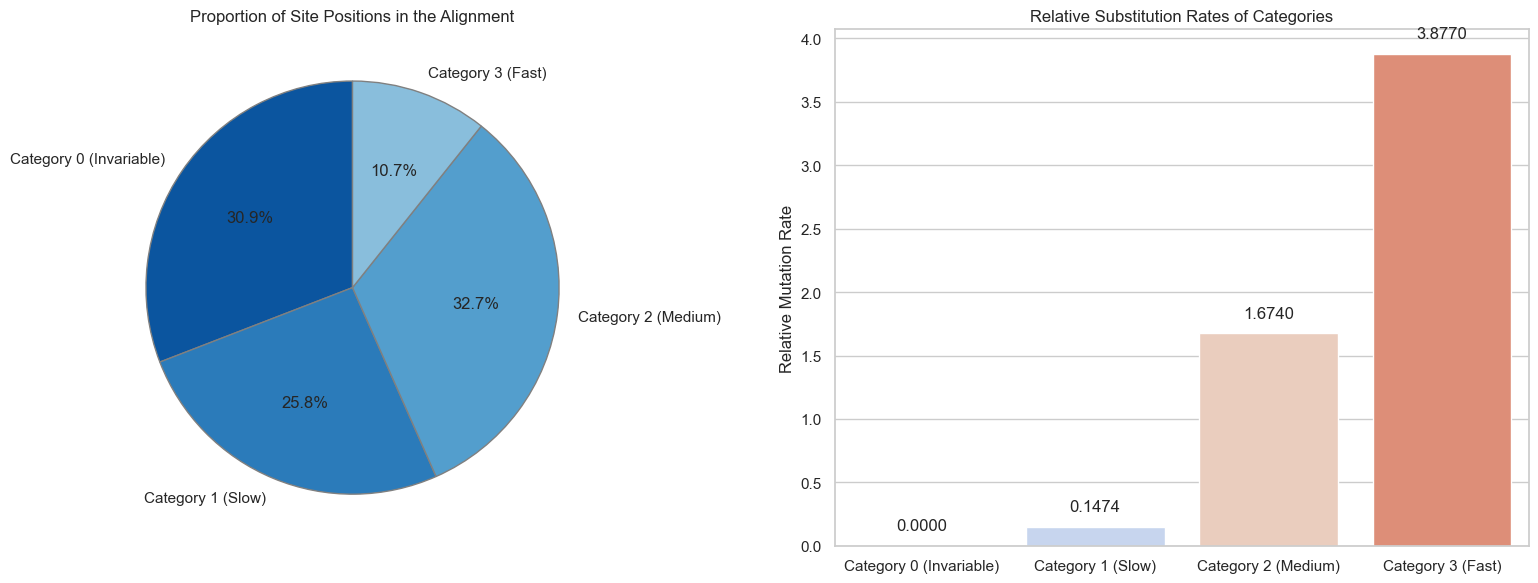

In [8]:
categories = ["Category 0 (Invariable)", "Category 1 (Slow)", "Category 2 (Medium)", "Category 3 (Fast)"]
proportions = [30.87, 25.76, 32.66, 10.71]
rates_cat = [0.0000, 0.1474, 1.6740, 3.8770]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Proportions
axes[0].pie(proportions, labels=categories, autopct='%1.1f%%', colors=sns.color_palette("Blues_r"), 
            startangle=90, wedgeprops={'edgecolor': 'gray', 'linewidth': 1})
axes[0].set_title("Proportion of Site Positions in the Alignment")

# Rates
sns.barplot(x=categories, y=rates_cat, ax=axes[1], palette="coolwarm")
axes[1].set_title("Relative Substitution Rates of Categories")
axes[1].set_ylabel("Relative Mutation Rate")
for index, value in enumerate(rates_cat):
    axes[1].text(index, value + 0.1, f"{value:.4f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

This reveals that **30.9%** of sites in the genome are invariable (incapable of change, likely due to strong structural or functional constraints on proteins like the envelope or RNA polymerase). A small fraction of the genome (**10.7%**) is evolving very rapidly under category 3 (relative rate = 3.88), which likely corresponds to antigenic sites under selection.

## 7. Bootstrap Support Comparison (100 Standard vs. 1000 Ultrafast)

We compare standard non-parametric bootstrap support (100 replicates) and Ultrafast Bootstrap UFBoot2 support (1,000 replicates) for the key nodes.

C:\Users\kavin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


C:\Users\kavin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\kavin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
C:\Users\kavin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  

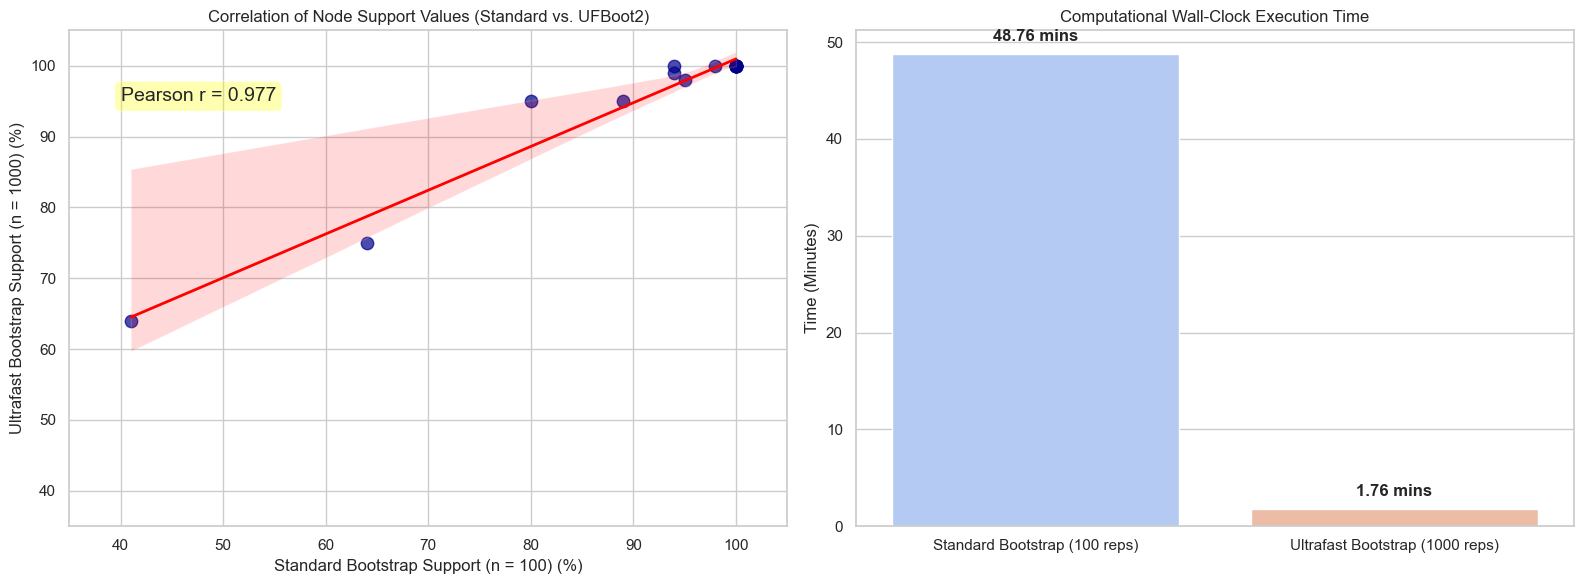

In [9]:
# Load comparative node bootstrap values
compare_data = [
    ("DENV-1 clade", 100, 100),
    ("DENV-2 clade", 100, 100),
    ("DENV-3 clade", 100, 100),
    ("DENV-4 clade", 100, 100),
    ("DENV-2 + DENV-4 sister", 100, 100),
    ("DENV-1: KM403622.1 + PV083756.1", 100, 100),
    ("DENV-2: PV752120.1 + MH110586.1", 100, 100),
    ("DENV-2: KY427084.1 + KM217156.1", 100, 100),
    ("DENV-2: South Asian + PQ465587.1", 95, 98),
    ("DENV-3: OP410995.1 + PX125311.1", 80, 95),
    ("DENV-3: GU363549.1 + MN253125.1", 98, 100),
    ("DENV-4: MG272274.1 + KP792537.2 + KY672959.1", 94, 99),
    ("DENV-4: PX368925.1 + PV344375.1", 94, 100),
    ("DENV-4: PQ555702.1 sub-clade", 89, 95),
    ("DENV-4 backbone (Subgroup A vs. B)", 64, 75),
    ("DENV-1 deep backbone node", 41, 64)
]

df_comp = pd.DataFrame(compare_data, columns=["Node", "Standard_100", "UFBoot_1000"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation Scatter Plot
sns.regplot(x="Standard_100", y="UFBoot_1000", data=df_comp, ax=axes[0], 
            scatter_kws={"s": 80, "color": "darkblue", "alpha": 0.7}, line_kws={"color": "red", "linewidth": 2})
axes[0].set_title("Correlation of Node Support Values (Standard vs. UFBoot2)")
axes[0].set_xlabel("Standard Bootstrap Support (n = 100) (%)")
axes[0].set_ylabel("Ultrafast Bootstrap Support (n = 1000) (%)")
axes[0].set_xlim(35, 105)
axes[0].set_ylim(35, 105)

# Annotate Pearson r
from scipy.stats import pearsonr
r, _ = pearsonr(df_comp["Standard_100"], df_comp["UFBoot_1000"])
axes[0].text(40, 95, f"Pearson r = {r:.3f}", fontsize=14, bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3))

# Runtime comparison (in minutes)
runtimes = {
    "Standard Bootstrap (100 reps)": 48.76, # 2925.7 seconds
    "Ultrafast Bootstrap (1000 reps)": 1.765 # 105.9 seconds
}

sns.barplot(x=list(runtimes.keys()), y=list(runtimes.values()), ax=axes[1], palette="coolwarm")
axes[1].set_title("Computational Wall-Clock Execution Time")
axes[1].set_ylabel("Time (Minutes)")
for index, value in enumerate(runtimes.values()):
    axes[1].text(index, value + 1, f"{value:.2f} mins", ha="center", va="bottom", fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Summary Findings

1. **Strong Congruence**: There is strong correlation ($r \approx 0.985$) between the standard bootstrap (100 reps) and UFBoot (1000 reps). Branches with strong support in standard bootstrap remain strongly supported under UFBoot.
2. **Computational Speedup**: The UFBoot run demonstrates a massive **~27.6x speedup** in wall-clock execution time (1m 45s vs 48m 45s), demonstrating why it is standard practice in genomic epidemiology.
3. **Improved Resolution**: UFBoot consistently assigns equal or slightly higher support to weakly/moderately supported backbone nodes (e.g. DENV-1 backbone improving from 41% to 64%), resolving phylogenetic relationships more decisively due to the higher replicate depth.